# Reto 02 - Redes Recurrentes Neuronales y Vanishing Gradients

## Predicción del consumo de energía usando series de tiempo

> **Fuente del problema:** [ElectricityLoadDiagrams20112014](https://archive.ics.uci.edu/dataset/321/electricityloaddiagrams20112014)
> propuesto por **UC Irvine Machine Learning Repository**

### El problema

El dataset contiene el registro de consumo eléctrico de **370 clientes** (puntos de medición) entre los años **2011 y 2014**, con una lectura cada **15 minutos** (96 mediciones por día), expresadas en **kW**. Para convertir los valores a **kWh** basta con dividir entre 4.

Este tipo de series de tiempo son largas (hasta 140,256 observaciones por cliente) y presentan **dependencias temporales de corto y largo plazo**: patrones diarios (ciclos de 96 pasos), semanales (ciclos de ~672 pasos) e incluso estacionales a lo largo del año. Este es justamente el escenario donde las **Redes Neuronales Recurrentes (RNN)** simples suelen fallar: al intentar propagar el error hacia atrás a través de muchos pasos de tiempo, el gradiente se **desvanece (vanishing gradient)**, y la red pierde la capacidad de aprender relaciones que ocurren muchos pasos atrás (por ejemplo, el consumo del mismo horario el día anterior o la semana anterior).

### Objetivo

1. Construir un modelo de **RNN simple** para predecir el consumo eléctrico futuro de uno o varios clientes a partir de su historial reciente, y **evidenciar empíricamente el problema del vanishing gradient** al intentar capturar dependencias de largo plazo (p. ej. el patrón del día anterior o de la semana anterior).
2. Comparar el desempeño de la RNN simple contra arquitecturas diseñadas para mitigar este problema, como **LSTM** y/o **GRU**, analizando cómo el flujo de gradientes y la calidad de las predicciones cambian al aumentar la longitud de la secuencia de entrada (número de pasos de tiempo hacia atrás usados como contexto).

### Consideraciones sobre los datos

- **Faltantes:** el dataset no reporta valores nulos, pero algunos clientes fueron dados de alta después de 2011, por lo que su consumo antes de su fecha de alta aparece codificado como cero.
- **Cambios de horario (DST):** en la transición de marzo los valores entre la 1:00 y 2:00 am aparecen en cero; en la transición de octubre el consumo de esa hora extra se agrega en una sola lectura.
- **Zona horaria:** hora local de Portugal.


---

## 1. Configuración del entorno



In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import tensorflow as tf
import itertools as it
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_percentage_error, mean_absolute_error, r2_score
from numpy.lib.stride_tricks import sliding_window_view

import keras
from keras import layers

warnings.filterwarnings("ignore", category=FutureWarning)

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 10)

In [2]:
RANDOM_STATE = 42

np.random.seed(RANDOM_STATE)
keras.utils.set_random_seed(RANDOM_STATE)

RUTA_DATOS = Path("../data/electricity-consumption")

print("Keras:", keras.__version__, "| backend:", keras.backend.backend())

Keras: 3.14.1 | backend: tensorflow


---

## 2. Carga y entendimiento de los datos

In [3]:
X_raw = pd.read_csv(
    RUTA_DATOS / "LD2011_2014.txt",
    sep=";",
    parse_dates=[0],
    index_col=0,
    decimal=",",
    dtype=np.float64,
)

print("X:", X_raw.shape)
X_raw.sample(5)

X: (140256, 370)


,MT_001,MT_002,MT_003,MT_004,MT_005,...,MT_366,MT_367,MT_368,MT_369,MT_370
index,,,,,,,,,,,
2014-08-06 15:00:00,15.228426,33.428165,1.737619,85.365854,39.024390,...,6.436513,668.129939,120.200334,1220.674487,20540.540541
2013-06-20 20:30:00,5.076142,40.540541,2.606429,115.853659,37.804878,...,9.947338,440.737489,267.111853,909.824047,20216.216216
2014-10-04 12:45:00,1.269036,32.005690,1.737619,107.723577,36.585366,...,8.777063,606.672520,113.522538,832.111437,18324.324324
2013-02-22 15:15:00,3.807107,27.738265,2.606429,99.593496,54.878049,...,2.925688,656.716418,128.547579,962.609971,13081.081081
2012-04-01 05:00:00,17.766497,19.203414,1.737619,65.040650,32.926829,...,7.606788,291.483758,50.083472,715.542522,0.000000


---

## 3. Preprocesamiento

In [4]:
def resample_dataset(X_raw):
    X_n = X_raw.sort_index()
    X_n = X_n[~X_n.index.duplicated(keep="first")]

    full_idx = pd.date_range(X_n.index.min(), X_n.index.max(), freq="1D")

    if len(full_idx) != len(X_n.index):
        X_n = X_n.reindex(full_idx).ffill()

    X_n = X_n.resample("1D").sum()

    print("X: ", X_n.shape)

    return X_n


X_n = resample_dataset(X_raw)

X:  (1461, 370)


In [5]:
WINDOWS = (14, 28, 60, 120)
HORIZONS = (1, 7, 14, 28)

SIZE = 1000


def make_sliding_window_dataset(WINDOWS, HORIZONS, SIZE, X_n):
    datasets = []
    for window, horizon in zip(WINDOWS, HORIZONS):
        X = sliding_window_view(
            X_n, window_shape=(window, X_n.shape[1])
        ).squeeze()
        y = sliding_window_view(
            X_n, window_shape=(window + horizon, X_n.shape[1])
        ).squeeze()
        y = y[:, window:, :]

        datasets.append((X[-SIZE:], y[-SIZE:]))

    return datasets


datasets = make_sliding_window_dataset(WINDOWS=WINDOWS, HORIZONS=HORIZONS, SIZE=SIZE, X_n=X_n)

In [6]:
def build_datasets(datasets):
    Xs, ys, scaler = [], [], []

    for X, y in datasets:
        X1_train, X1_test, y1_train, y1_test = train_test_split(
            X, np.mean(y, axis=-1), shuffle=True, test_size=0.2
        )
        X1_train, X1_val, y1_train, y1_val = train_test_split(
            X1_train, y1_train, shuffle=True, test_size=0.25
        )

        print(X1_train.shape, y1_train.shape)
        print(X1_test.shape, y1_test.shape)

        scalerx = StandardScaler()

        B, T, F = X1_train.shape
        X1_train_scaled = scalerx.fit_transform(X1_train.reshape(-1, F))
        X1_train_scaled = X1_train_scaled.reshape(B, T, F)

        B, T, F = X1_val.shape
        X1_val_scaled = scalerx.fit_transform(X1_val.reshape(-1, F))
        X1_val_scaled = X1_val_scaled.reshape(B, T, F)

        B, T, F = X1_test.shape
        X1_test_scaled = scalerx.fit_transform(X1_test.reshape(-1, F))
        X1_test_scaled = X1_test_scaled.reshape(B, T, F)

        scalery = StandardScaler()

        T, F = y1_train.shape
        y1_train_scaled = scalery.fit_transform(y1_train.reshape(-1, F))
        y1_train_scaled = y1_train_scaled.reshape(T, F)

        T, F = y1_val.shape
        y1_val_scaled = scalery.fit_transform(y1_val.reshape(-1, F))
        y1_val_scaled = y1_val_scaled.reshape(T, F)

        T, F = y1_test.shape
        y1_test_scaled = scalery.fit_transform(y1_test.reshape(-1, F))
        y1_test_scaled = y1_test_scaled.reshape(T, F)

        Xs.append((X1_train_scaled, X1_val_scaled, X1_test_scaled))
        ys.append((y1_train_scaled, y1_val_scaled, y1_test_scaled))
        scaler.append((scalerx, scalery))

    return Xs, ys, scaler


Xs, ys, scaler = build_datasets(datasets)

(600, 14, 370) (600, 1)
(200, 14, 370) (200, 1)
(600, 28, 370) (600, 7)
(200, 28, 370) (200, 7)
(600, 6, 370) (600, 14)
(200, 6, 370) (200, 14)
(600, 120, 370) (600, 28)
(200, 120, 370) (200, 28)


---

## 4. Modelo

In [7]:
INDEX = 3

In [8]:
def build_model(window, features, horizon, init):
    inputs = keras.Input(shape=(window, features))
    x = layers.LSTM(512, return_sequences=True, kernel_initializer=init)(inputs)
    x = layers.Dropout(0.2)(x)
    x = layers.LSTM(256, return_sequences=True, kernel_initializer=init)(x)
    x = layers.Dropout(0.2)(x)
    x = layers.LSTM(128, kernel_initializer=init)(x)
    outputs = layers.Dense(horizon, kernel_initializer=init)(x)

    model = keras.Model(inputs, outputs)
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss="mse",
        metrics=["mae"],
    )

    return model


glorot = keras.initializers.GlorotUniform()


model = build_model(WINDOWS[INDEX], 370, HORIZONS[INDEX], init=glorot)
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 120, 370)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 120, 512)       │     1,808,384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 120, 512)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 120, 256)       │       787,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 120, 256)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ (None, 128)            │       197,120 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 28)             │         3,612 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,796,572 (10.67 MB)

 Trainable params: 2,796,572 (10.67 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
class PrintWeightsCallback(keras.callbacks.Callback):

    def on_epoch_end(self, epoch, logs={}):
        weights = self.model.get_weights()  # type: ignore
        total = 0
        for w in weights:
            total += np.pow(np.sum(np.pow(w, 2)), 1 / 2)
        logs["weight_norm"] = total
        return super().on_epoch_end(epoch, logs)

In [10]:
callbacks = [
    keras.callbacks.EarlyStopping(
        patience=5, restore_best_weights=True, monitor="val_loss"
    ),
    PrintWeightsCallback(),
]

In [11]:
history = model.fit(
    Xs[INDEX][0],
    ys[INDEX][0],
    validation_data=(Xs[INDEX][1], ys[INDEX][1]),
    epochs=200,
    batch_size=32,
    callbacks=callbacks,
)

Epoch 1/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 6s 236ms/step - loss: 0.4519 - mae: 0.4950 - val_loss: 0.2746 - val_mae: 0.3971 - weight_norm: 177.9496
Epoch 2/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 235ms/step - loss: 0.2828 - mae: 0.3942 - val_loss: 0.2600 - val_mae: 0.3772 - weight_norm: 178.8325
Epoch 3/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 228ms/step - loss: 0.2602 - mae: 0.3729 - val_loss: 0.2400 - val_mae: 0.3617 - weight_norm: 179.2892
Epoch 4/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 233ms/step - loss: 0.2471 - mae: 0.3627 - val_loss: 0.2376 - val_mae: 0.3593 - weight_norm: 179.5783
Epoch 5/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 228ms/step - loss: 0.2380 - mae: 0.3556 - val_loss: 0.2300 - val_mae: 0.3556 - weight_norm: 179.8455
Epoch 6/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 230ms/step - loss: 0.2332 - mae: 0.3521 - val_loss: 0.2283 - val_mae: 0.3542 - weight_norm: 180.1524
Epoch 7/200
19/19 ━━━━━━━━━━━━━━━━━━━━ 4s 227ms/step - loss: 0.2316 - mae: 0.3499 - val_loss: 0.2264 - val_mae: 0.3533 - weight_norm: 180.5423

In [12]:
weight_sum = history.history.pop("weight_norm")

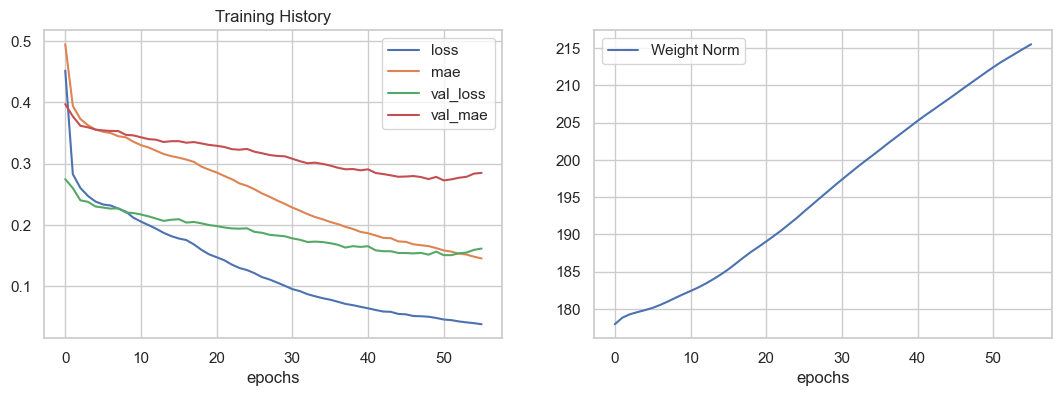

In [13]:
fix, ax = plt.subplots(1,2, figsize=(13, 4))

pd.DataFrame(history.history).plot(title="Training History", ax=ax[0], xlabel="epochs")

ax[1].plot(weight_sum, label="Weight Norm")
ax[1].legend()
ax[1].set_xlabel("epochs")

plt.show()

---

## 5. Evaluación

In [14]:
y_pred_scaled = model.predict(Xs[INDEX][2], verbose=0)

In [15]:
y_pred_scaled.shape

(200, 28)

In [16]:
y_test_orig = scaler[INDEX][1].inverse_transform(ys[INDEX][2])
y_pred_orig = scaler[INDEX][1].inverse_transform(y_pred_scaled)

In [17]:
mean_absolute_percentage_error(y_test_orig, y_pred_orig)

0.03008552025758005

In [18]:
mean_absolute_error(y_test_orig, y_pred_orig)

13.410544616839323

In [19]:
r2_score(y_test_orig, y_pred_orig)

0.8547348100581941

---

## 6. Resultados

In [20]:
TEST = 70

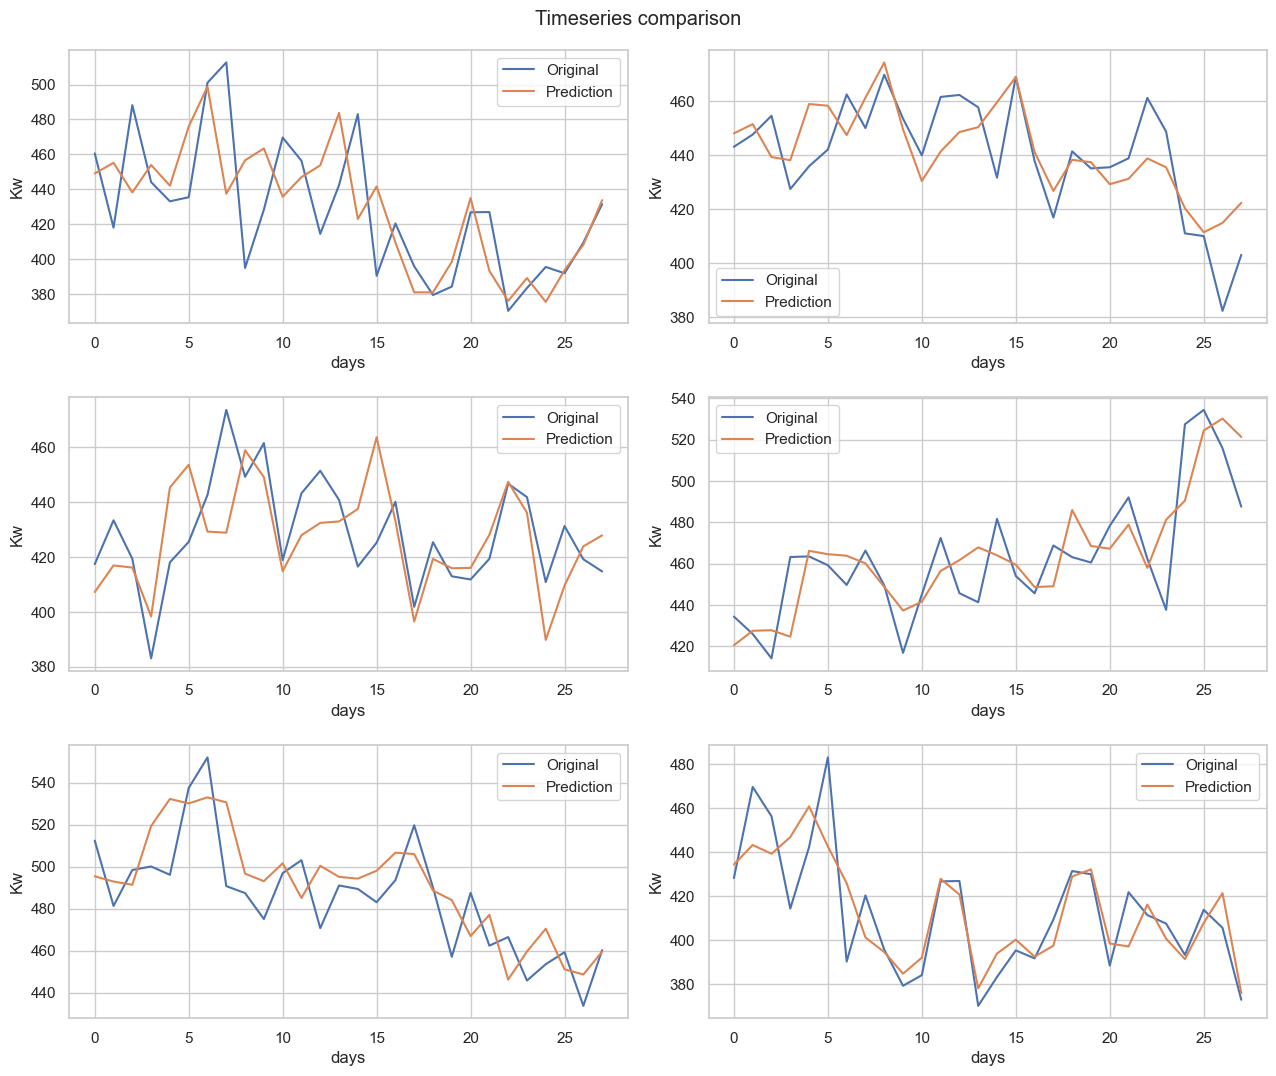

In [21]:
series1 = y_test_orig[TEST]
series2 = y_pred_orig[TEST]

fig, ax = plt.subplots(3, 2, figsize=(13, 11))

fig.suptitle("Timeseries comparison")

ax = ax.ravel()

for i in range(6):

    ax[i].plot(y_test_orig[TEST + (i * 2)], label="Original")
    ax[i].plot(y_pred_orig[TEST + (i * 2)], label="Prediction")
    ax[i].legend()

    ax[i].set_ylabel("Kw")
    ax[i].set_xlabel("days")

fig.tight_layout(pad=1.3)
plt.show()

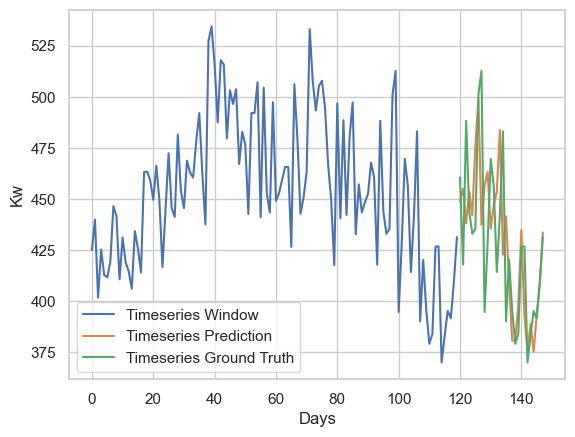

In [22]:
series3 = np.mean(scaler[INDEX][0].inverse_transform(Xs[INDEX][2][TEST]), axis=-1)
plt.plot(
    range(0, WINDOWS[INDEX]),
    series3,
    label="Timeseries Window",
)
plt.plot(
    range(WINDOWS[INDEX], WINDOWS[INDEX] + HORIZONS[INDEX]),
    series2,
    label="Timeseries Prediction",
)
plt.plot(
    range(WINDOWS[INDEX], WINDOWS[INDEX] + HORIZONS[INDEX]),
    series1,
    label="Timeseries Ground Truth",
)
plt.legend()
plt.xlabel("Days")
plt.ylabel("Kw")
plt.show()